datos procesados sin aumentacion


Train: 800 | Test: 200
Balanceo train:
IsToxic
0    430
1    370
Name: count, dtype: int64

--- Logistic Regression ---
              precision    recall  f1-score   support

   No tóxico       0.73      0.87      0.79       108
      Tóxico       0.80      0.62      0.70        92

    accuracy                           0.76       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.76      0.76      0.75       200



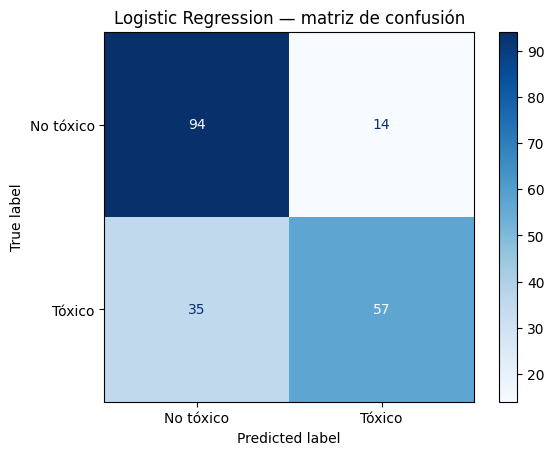


Train F1: 0.938
Test F1:  0.750
Diferencia: 0.188 ⚠️ Overfitting


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar datos procesados
df = pd.read_csv('../../data/processed/comments_processed.csv')

# Split
X = df['text_clean']
y = df['IsToxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Balanceo train:\n{y_train.value_counts()}")

# Vectorización TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigramas y bigramas
    min_df=2             # ignorar términos que aparecen menos de 2 veces
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Modelo base — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = lr.predict(X_test_tfidf)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred, target_names=['No tóxico', 'Tóxico']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No tóxico', 'Tóxico'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_logreg.png', dpi=150)
plt.show()

# Overfitting check
y_train_pred = lr.predict(X_train_tfidf)
train_f1 = classification_report(y_train, y_train_pred, output_dict=True)['weighted avg']['f1-score']
test_f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1:.3f}")
print(f"Test F1:  {test_f1:.3f}")
print(f"Diferencia: {abs(train_f1 - test_f1):.3f} {'✅ OK' if abs(train_f1 - test_f1) < 0.05 else '⚠️ Overfitting'}")

###Explicación:

## Modelo Base — Logistic Regression

### Vectorización
Se aplicó **TF-IDF** (Term Frequency-Inverse Document Frequency) sobre el texto preprocesado con los siguientes parámetros:
- `max_features=5000` — vocabulario limitado a las 5000 palabras más relevantes
- `ngram_range=(1,2)` — unigramas y bigramas para capturar contexto local
- `min_df=2` — se ignoran términos que aparecen menos de 2 veces

### Resultados

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| No tóxico | 0.73 | 0.87 | 0.79 |
| Tóxico | 0.80 | 0.62 | 0.70 |
| **Weighted avg** | **0.76** | **0.76** | **0.75** |

**Accuracy:** 0.76

### Análisis de Overfitting

| | F1 |
|---|---|
| Train | 0.938 |
| Test | 0.750 |
| Diferencia | 0.188 ⚠️ |

El modelo presenta overfitting significativo (18.8%), superando el umbral máximo de 5 puntos establecido en los requisitos del proyecto. Esto indica que la Logistic Regression memoriza el conjunto de entrenamiento en lugar de generalizar.

### Observaciones
- El **recall de la clase tóxica es bajo (0.62)** — el modelo no detecta el 38% de los comentarios tóxicos reales. En un contexto de moderación de contenido esto es crítico, ya que es preferible marcar algún falso positivo antes que dejar pasar mensajes de odio.
- El overfitting se abordará en la siguiente fase mediante un **Voting Ensemble** (Logistic Regression + SVM + XGBoost) con optimización de hiperparámetros via **Optuna**.

datos procesados con aumentacion

Train: 860 | Test: 216
Balanceo train:
IsToxic
1    430
0    430
Name: count, dtype: int64

--- Logistic Regression ---
              precision    recall  f1-score   support

   No tóxico       0.72      0.70      0.71       108
      Tóxico       0.71      0.73      0.72       108

    accuracy                           0.72       216
   macro avg       0.72      0.72      0.72       216
weighted avg       0.72      0.72      0.72       216



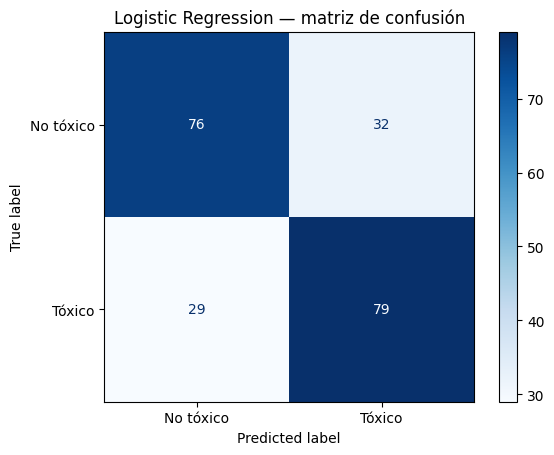


Train F1: 0.940
Test F1:  0.718
Diferencia: 0.222 ⚠️ Overfitting


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar datos procesados
df = pd.read_csv('../../data/processed/comments_augmented.csv')

# Split
X = df['text_clean']
y = df['IsToxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Balanceo train:\n{y_train.value_counts()}")

# Vectorización TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigramas y bigramas
    min_df=2             # ignorar términos que aparecen menos de 2 veces
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Modelo base — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = lr.predict(X_test_tfidf)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred, target_names=['No tóxico', 'Tóxico']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No tóxico', 'Tóxico'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_logreg.png', dpi=150)
plt.show()

# Overfitting check
y_train_pred = lr.predict(X_train_tfidf)
train_f1 = classification_report(y_train, y_train_pred, output_dict=True)['weighted avg']['f1-score']
test_f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1:.3f}")
print(f"Test F1:  {test_f1:.3f}")
print(f"Diferencia: {abs(train_f1 - test_f1):.3f} {'✅ OK' if abs(train_f1 - test_f1) < 0.05 else '⚠️ Overfitting'}")

### Comparativa con Data Augmentation

| | Sin augmentación | Con augmentación |
|---|---|---|
| Test F1 | 0.750 | 0.718 |
| Overfitting | 0.188 | 0.222 |
| Recall tóxico | 0.62 | 0.73 |

La duplicación simple de la clase minoritaria incrementó el overfitting sin mejorar
el F1 general. Se descarta para el pipeline final y se continúa con el dataset
original. La mejora en recall tóxico no compensa la pérdida de generalización.